In [1]:
# 🎯 Unsupervised Learning

# 👉 Unsupervised Learning is a type of machine learning where the model learns from data without labels.

In [2]:
# 🔍 Compare with Supervised Learning
# Type	        Data	         Example
# Supervised	Input + Output	Spam / Not Spam
# Unsupervised	Only Input	    Group similar customers

In [3]:
# 🧠 Intuition

# Think like this:

# You are given customer data
# (no labels like rich/poor)

# Model automatically finds groups

# 👉 No “correct answer” is provided
# 👉 Model discovers patterns on its own

In [4]:
# 🔷 2. Types of Unsupervised Learning

# There are 2 main types:

    # 🔹 1. Clustering
        
        # Group similar data points together.
        
        # Algorithms:
            # K-Means Clustering
            # Hierarchical Clustering
            # DBSCAN

    # 🔹 2. Dimensionality Reduction

        # Reduce number of features while keeping important information.

        # Algorithms:
            # Principal Component Analysis

In [5]:
# 🔷 3. When Do We Use Unsupervised Learning?

# Use it when:
    
    # ✔ No labeled data
    # ✔ Want to find hidden patterns
    # ✔ Data exploration

# Examples:

    # Customer segmentation
    # Anomaly detection
    # Data compression

In [7]:
# 🔷 4. Start with Clustering — K-Means

# K-Means groups data into K clusters based on similarity

In [8]:
# 🧠 Intuition

# Example:

    # You have customers:
    
        # Income	Spending
        # 20000	    20
        # 30000	    30
        # 80000	    80
        # 100000	90

    # 👉 Model groups them into:
    
    # Low income / low spending
    # High income / high spending

In [9]:
# 🔷 6. How K-Means Works (Step-by-Step)
# Step 1: Choose K (number of clusters)
    # K = 2
# Step 2: Pick random cluster centers
    # Cluster 1 center
    # Cluster 2 center
# Step 3: Assign points to nearest center
# Step 4: Update centers (mean of points)
# Step 5: Repeat until stable

In [10]:
# 🔷 7. Code Implementation

In [1]:
# Step 1: Import

import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

In [2]:
# Step 2: Create Data

data = {
    "income":[20000,30000,50000,80000,100000],
    "spending":[20,30,50,80,90]
}

df = pd.DataFrame(data)

In [3]:
# Step 3: Apply K-Means

model = KMeans(n_clusters=2, random_state=42)

df["cluster"] = model.fit_predict(df)

print(df)

   income  spending  cluster
0   20000        20        0
1   30000        30        0
2   50000        50        0
3   80000        80        1
4  100000        90        1


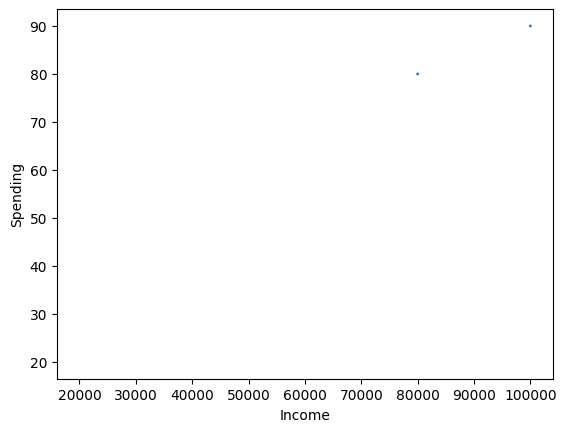

In [4]:
# Step 5: Visualization

plt.scatter(df["income"], df["spending"], df["cluster"])

plt.xlabel("Income")
plt.ylabel("Spending")

plt.show()

In [5]:
# 🔷 8. Important Concept — Centroid

# Each cluster has a center called:

# 👉 Centroid (mean of points)

# You can see it:

print(model.cluster_centers_)

[[3.33333333e+04 3.33333333e+01]
 [9.00000000e+04 8.50000000e+01]]


In [9]:
# K = 3

import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

data = {
    "income":[20000,30000,50000,80000,100000],
    "spending":[20,30,50,80,90]
}

df = pd.DataFrame(data)

model = KMeans(n_clusters=3, random_state=42)

df["cluster"] = model.fit_predict(df)

print(df)

   income  spending  cluster
0   20000        20        0
1   30000        30        0
2   50000        50        2
3   80000        80        1
4  100000        90        1


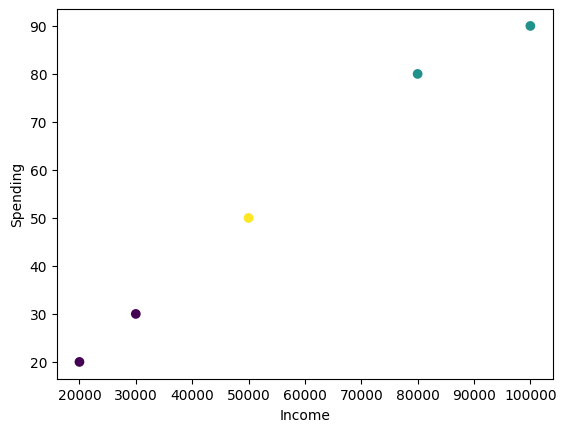

In [10]:
plt.scatter(df["income"], df["spending"], c=df["cluster"])

plt.xlabel("Income")
plt.ylabel("Spending")

plt.show()

In [8]:
# 🔷 9. Problem with K-Means

# 👉 You must choose K manually

# So question is:

# ❓ How to choose best K?

# 👉 Elbow Method to find optimal K

In [2]:
# 🔷 How to Choose K in K-Means?

# 👉 We use the Elbow Method

# 🔷 1. What is the Elbow Method?

# 📌 The Elbow Method helps find the optimal number of clusters (K) by measuring how well data fits into clusters.

# 🔷 2. Key Idea — WCSS

# 📌 WCSS = Within-Cluster Sum of Squares

# 👉 It measures how close data points are to their cluster center

# Low WCSS → tight clusters (good)
# High WCSS → scattered clusters (bad)

# 🧠 Intuition
# K = 1 → very high WCSS ❌
# K increases → WCSS decreases ✔

# But after a point:

# 👉 Improvement becomes very small

# That point = Elbow Point


# 🔷 3. Visual Idea

# WCSS
# │
# │\
# │ \
# │  \
# │   \__
# │       \__
# │           \__
# └───────────────
#         K

# 👉 The “bend” (elbow) is the best K

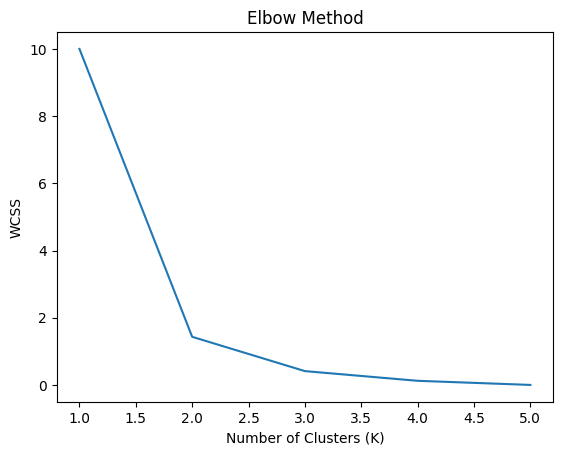

In [7]:
# 🔷 4. Code Implementation

# Step 1: Import
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

data = {
    "income":[20000,30000,50000,80000,100000],
    "spending":[20,30,50,80,90]
}

df = pd.DataFrame(data)

# Step 2: Use Same Dataset
X = df[["income", "spending"]]

# Always scale data before K-Means
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 3: Calculate WCSS
wcss = []

# You are calculating it for different values of K (1 to 6)
for i in range(1, 6):
    model = KMeans(n_clusters=i, random_state=42)
    model.fit(X_scaled)
    # inertia_ = WCSS (Within-Cluster Sum of Squares)
    wcss.append(model.inertia_)

# Step 4: Plot Elbow Graph
plt.plot(range(1, 6), wcss)
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method")

plt.show()

In [8]:
# 📊 What you should expect

# WCSS will decrease as K increases
# Look for a point where the decrease slows down → that’s the elbow point

# 🔷 5. How to Read the Graph

# 👉 Look for the point where:

# Curve bends sharply
# After that, improvement slows

# K = 3 → Best choice

# 🔷 6. Why This Works

# Because:

# Initially adding clusters improves fit a lot
# Later, improvement becomes small

# 👉 So we stop at the elbow

# 🔷 7. Common Mistakes

# ❌ Choosing very high K
# ❌ Ignoring the elbow point
# ❌ Using raw data without scaling